In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("german_credit_data.csv")
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [4]:
df.describe(include= "all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [6]:
df.drop(columns= 'Unnamed: 0' , inplace = True)

In [7]:
#filling NULL value
df['Saving accounts'] = df['Saving accounts'].fillna('None')
df['Checking account'] = df['Checking account'].fillna('None')

In [8]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,None,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,None,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [9]:
df.isna().sum()

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


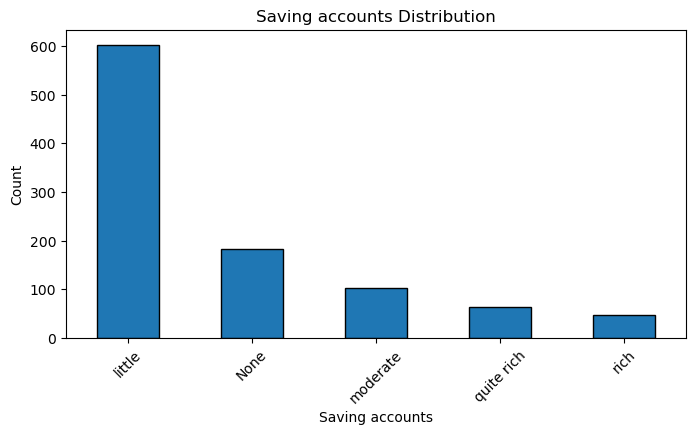

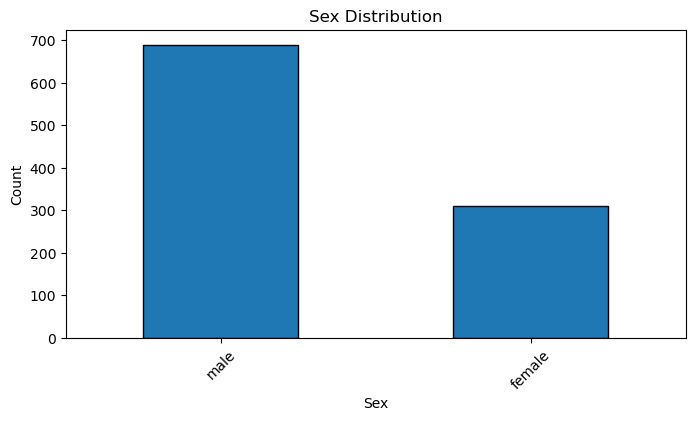

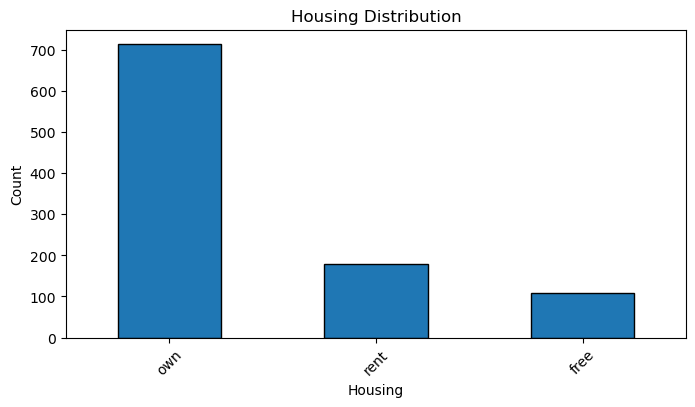

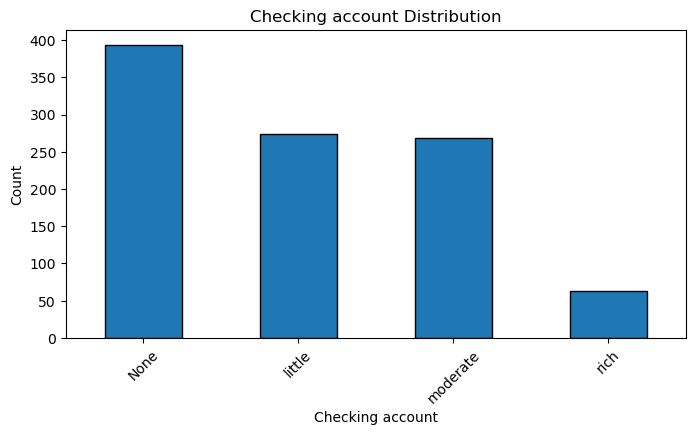

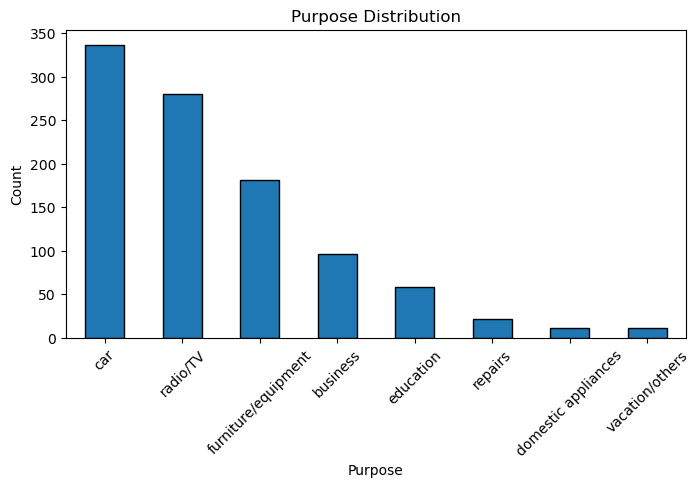

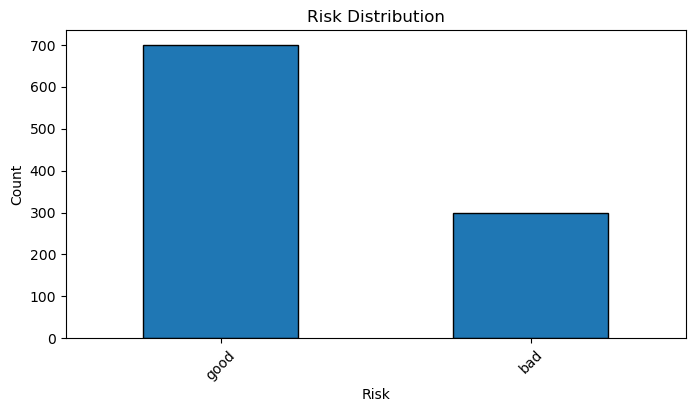

In [12]:
cat_cols = ['Saving accounts', 'Sex', 'Housing',
            'Checking account', 'Purpose', 'Risk']

for col in cat_cols:
    plt.figure(figsize=(8,4))
    df[col].value_counts().plot(
        kind='bar',
        edgecolor='black'
    )

    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

In [13]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

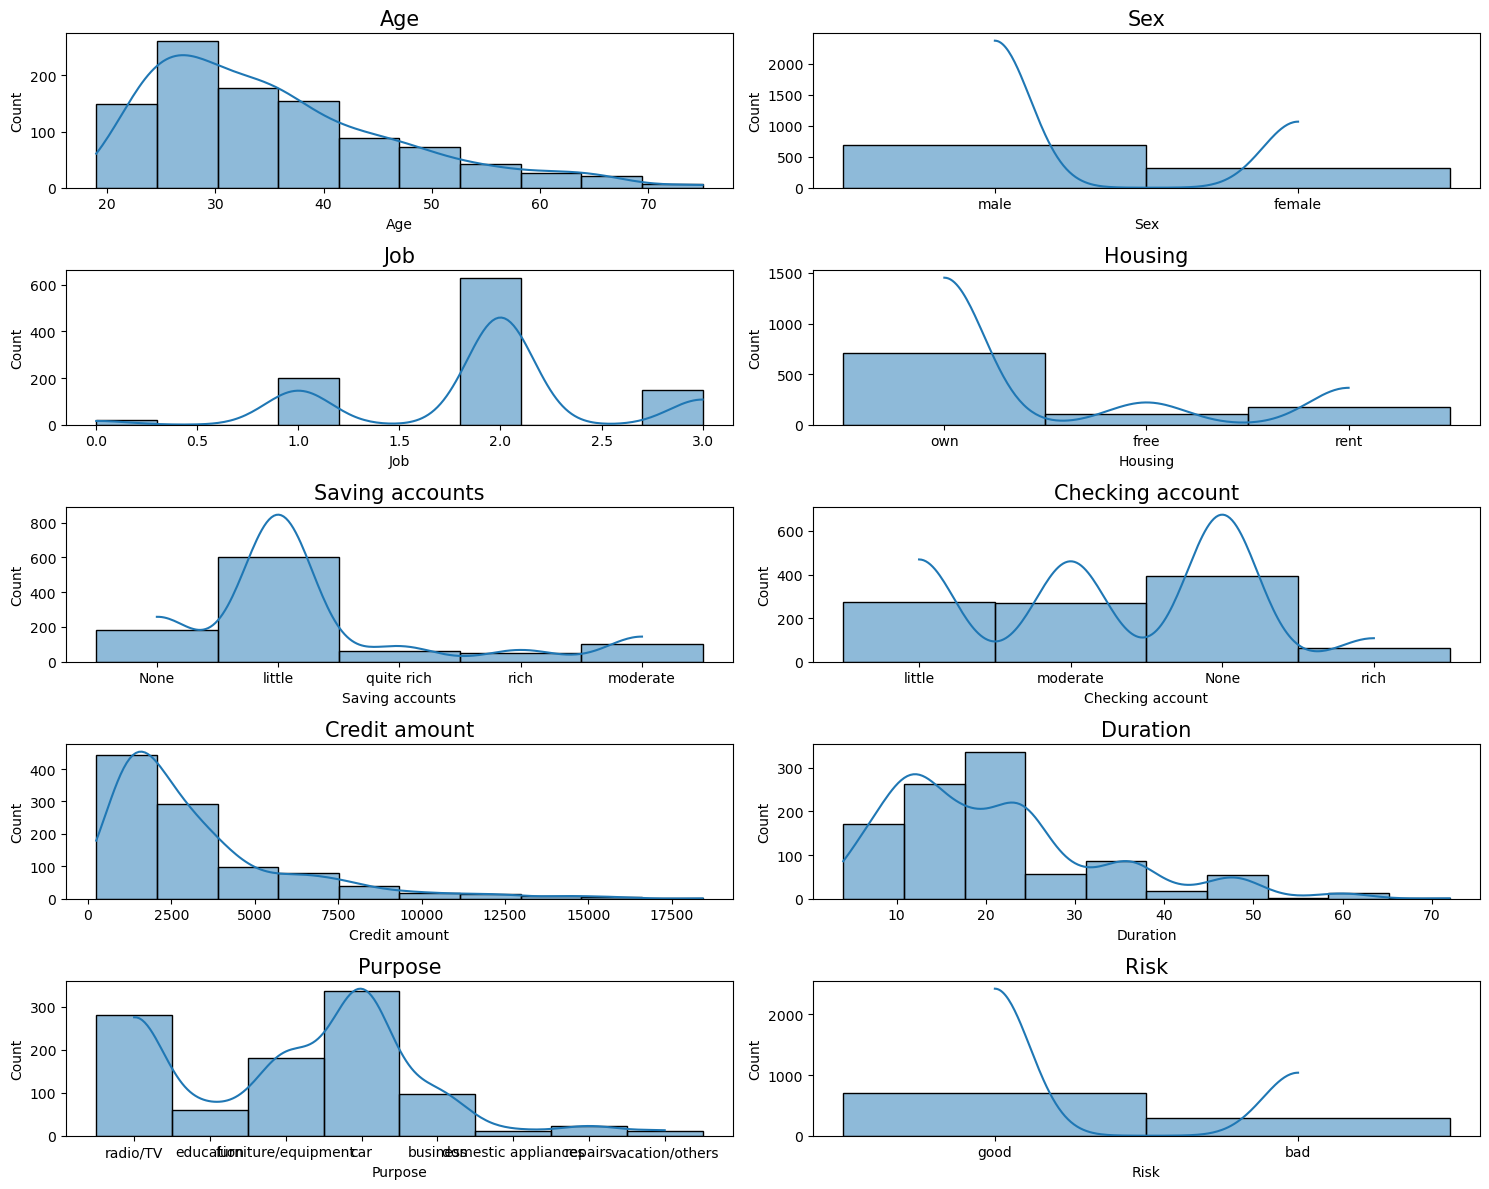

In [14]:
plt.figure(figsize = (15 , 12 ))
def plotting(var , num):
    plt.subplot(5 ,2 , num)
    sns.histplot( data = df , x = var , kde = True , bins = 10 ,palette = "bright")
    plt.title(var , fontsize = 15)

plotting('Age' , 1)
plotting('Sex' , 2)
plotting('Job' , 3)
plotting('Housing' , 4)
plotting('Saving accounts' , 5)
plotting('Checking account' , 6)
plotting('Credit amount' , 7)
plotting('Duration' , 8)
plotting('Purpose' , 9)
plotting('Risk' , 10)

plt.tight_layout()
plt.show()

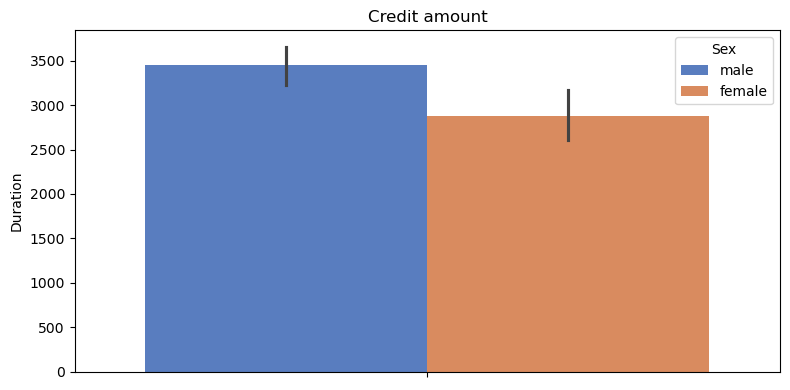

In [15]:
plt.figure(figsize = (8 , 4))
sns.barplot(y = 'Credit amount' , hue = 'Sex' , data = df, palette = 'muted')
plt.title('Credit amount' , fontsize = 12)
plt.ylabel('Duration')
plt.tight_layout()
plt.show()

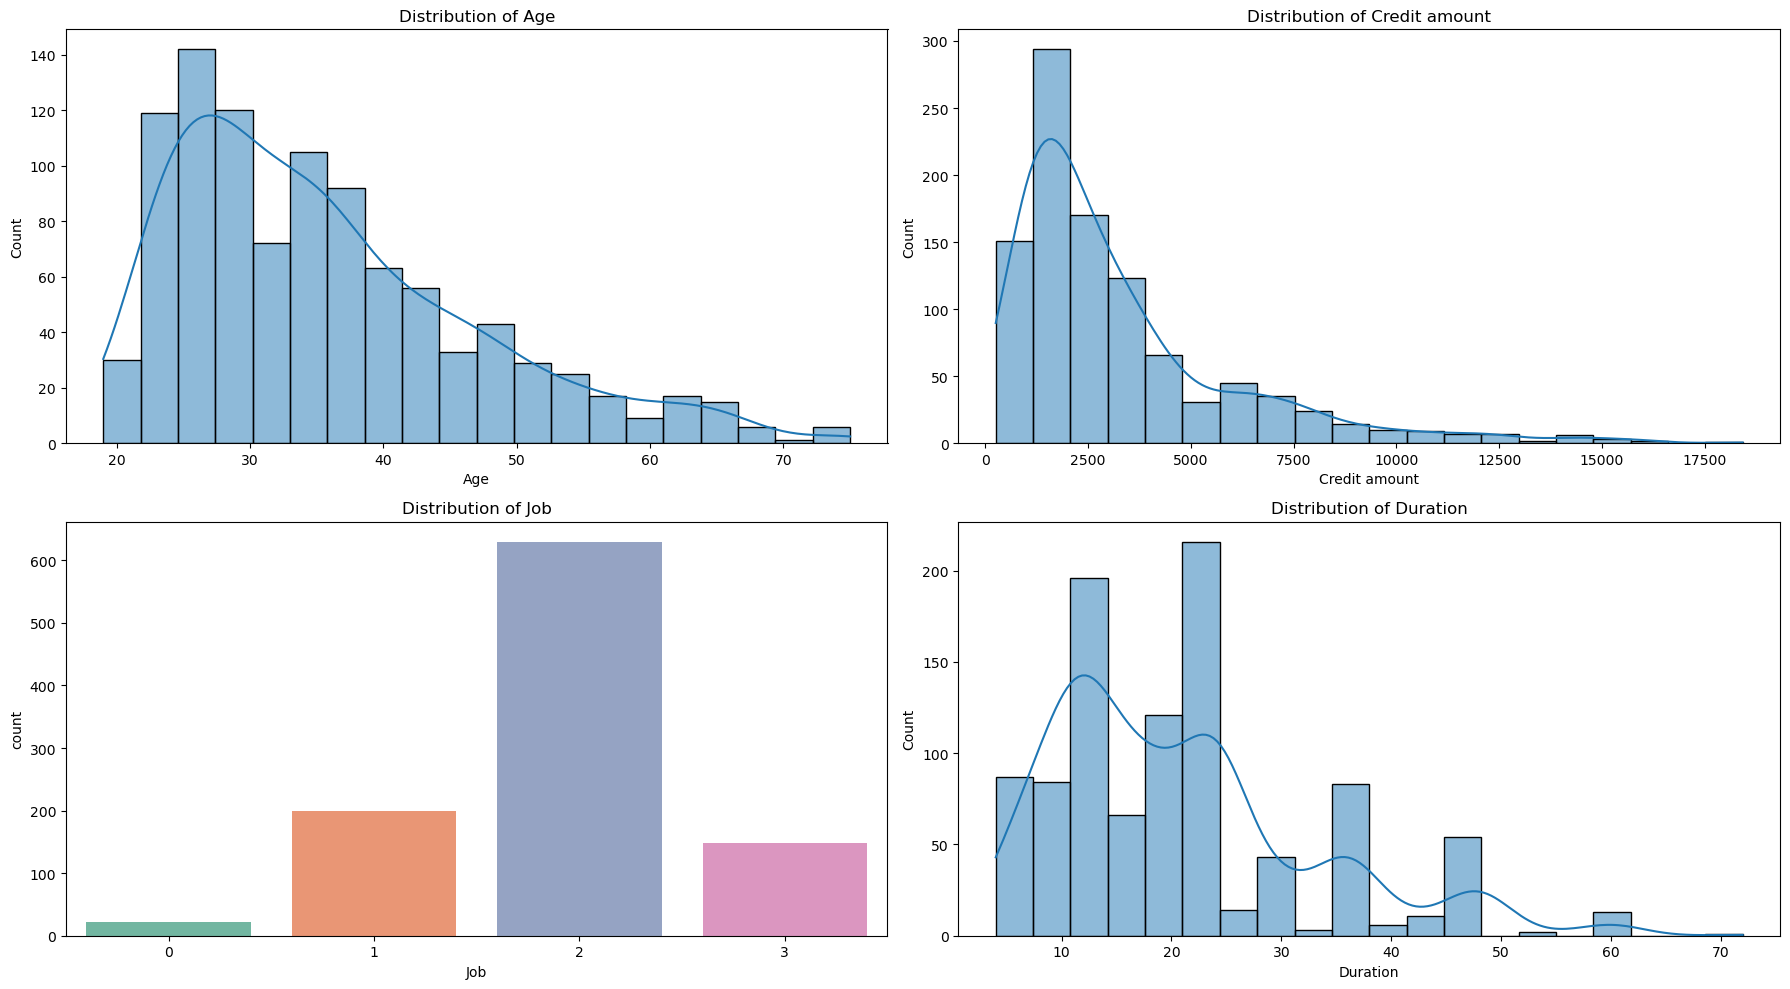

In [16]:
#count plot of numerical datas
plt.figure(figsize=(18 , 10))


num_col = ['Age', 'Credit amount', 'Job', 'Duration']

for i, col in enumerate(num_col):

    plt.subplot(2,2,i+1)

    if col == 'Job':
        sns.countplot(data=df, x=col, palette='Set2')
    else:
        sns.histplot(data=df, x=col, bins=20, kde=True)

    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [17]:
df.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


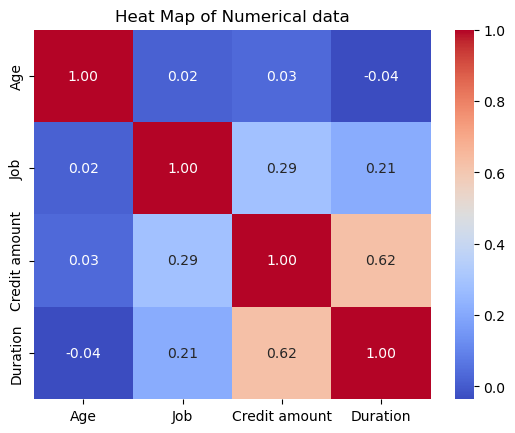

In [18]:
corr = df[['Age',	'Job',	'Credit amount',	'Duration']].corr()
sns.heatmap(corr , annot = True , cmap = 'coolwarm' , fmt = '.2f')
plt.title("Heat Map of Numerical data")
plt.show()

In [19]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,None,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,None,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


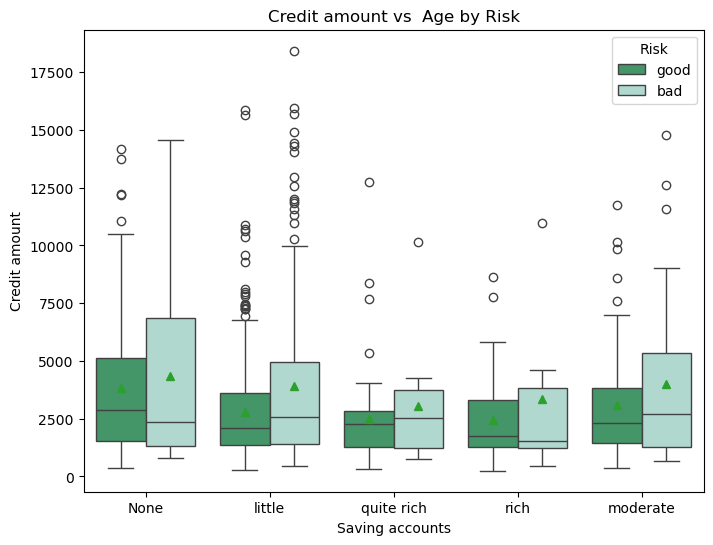

In [20]:
plt.figure(figsize = (8 , 6))
sns.boxplot(data = df , x = 'Saving accounts' , y = 'Credit amount' , hue = 'Risk' , palette= 'BuGn_r' , showmeans = True)
plt.title('Credit amount vs  Age by Risk')
plt.show()

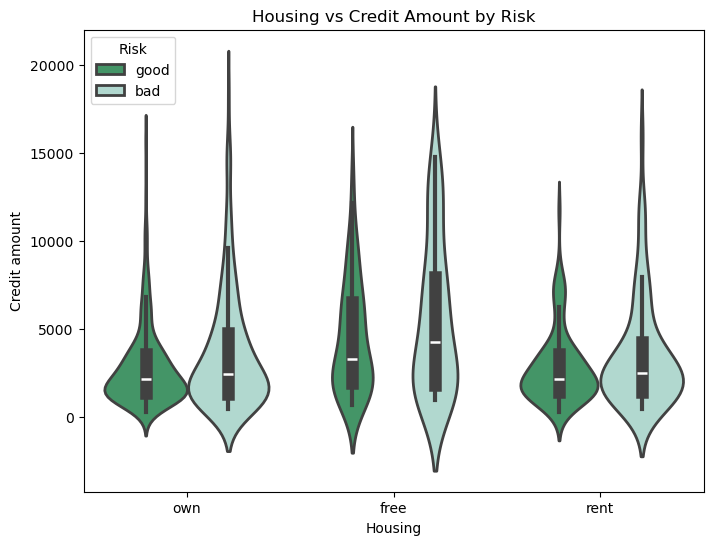

In [21]:
plt.figure(figsize = (8 , 6))
sns.violinplot(data = df , x = 'Housing' , y = 'Credit amount' , hue = 'Risk' , palette= 'BuGn_r', alpha = 1 , linewidth = 2)
plt.title("Housing vs Credit Amount by Risk")
plt.show()

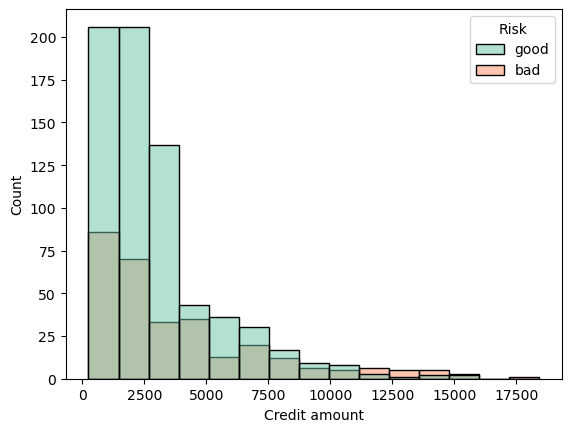

In [22]:
sns.histplot(data=df, x='Credit amount', hue='Risk' , palette= 'Set2' , bins = 15)
plt.show()

In [23]:
df['Risk'].value_counts()
#this are unbalance then using smote alorithum

Risk
good    700
bad     300
Name: count, dtype: int64

In [24]:
df.groupby('Risk')['Credit amount'].mean()

Risk
bad     3938.126667
good    2985.457143
Name: Credit amount, dtype: float64

In [25]:
pivot = pd.pivot_table(
    df,
    index = 'Saving accounts',
    columns = 'Risk',
    values = 'Credit amount',
    aggfunc = 'mean',
)
print(pivot)

Risk                     bad         good
Saving accounts                          
None             4362.062500  3809.847682
little           3925.557604  2773.101036
moderate         4006.970588  3077.086957
quite rich       3052.818182  2470.423077
rich             3364.666667  2460.357143


In [26]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,None,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,None,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [27]:
df['Housing'].value_counts()

Housing
own     713
rent    179
free    108
Name: count, dtype: int64

In [28]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [29]:
#lebal Encoding and One Hot Encoding
# lb -> SEX and RISK
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
df['Sex'] = lb.fit_transform(df['Sex'])
df['Risk'] = lb.fit_transform(df['Risk'])

# OHE -> exclude sex and risk
cat_col = ['Housing', 'Saving accounts', 'Checking account','Purpose']

num_col = ['Age' ,'Job', 'Credit amount', 'Duration']

#column Tranformation
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(drop = 'first' , handle_unknown= 'ignore' ) , cat_col),
        ('num' , StandardScaler() , num_col),
    ]
)

In [30]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,1,2,own,None,little,1169,6,radio/TV,1
1,22,0,2,own,little,moderate,5951,48,radio/TV,0
2,49,1,1,own,little,None,2096,12,education,1
3,45,1,2,free,little,little,7882,42,furniture/equipment,1
4,53,1,2,free,little,little,4870,24,car,0


In [31]:
print(df['Risk'].unique())

[1 0]


In [32]:
# To see the transformed data
X = df.drop('Risk', axis=1)
X_transformed = preprocessor.fit_transform(X)

In [33]:
# To see the transformed data
x_transfomerd_df = pd.DataFrame(
    X_transformed,
    columns= preprocessor.get_feature_names_out()
)
x_transfomerd_df.head(10)

,cat__Housing_own,cat__Housing_rent,cat__Saving accounts_little,cat__Saving accounts_moderate,cat__Saving accounts_quite rich,cat__Saving accounts_rich,cat__Checking account_little,cat__Checking account_moderate,cat__Checking account_rich,cat__Purpose_car,cat__Purpose_domestic appliances,cat__Purpose_education,cat__Purpose_furniture/equipment,cat__Purpose_radio/TV,cat__Purpose_repairs,cat__Purpose_vacation/others,num__Age,num__Job,num__Credit amount,num__Duration
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.766456,0.146949,-0.745131,-1.236478
1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.191404,0.146949,0.949817,2.248194
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.183312,-1.383771,-0.416562,-0.738668
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.831502,0.146949,1.634247,1.750384
4,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.535122,0.146949,0.566664,0.256953
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,-0.048022,-1.383771,2.050009,1.252574
6,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.535122,0.146949,-0.154629,0.256953
7,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.048022,1.677670,1.303197,1.252574
8,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.238742,-1.383771,-0.075233,-0.738668
9,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.663689,1.677670,0.695681,0.754763


In [34]:
# using pipeline and train the on LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
pipeline_LR = Pipeline(steps=[
    ('preprocessing' , preprocessor),
    ('model' , LogisticRegression(penalty='l2' , class_weight= 'balanced' ,  C=1.0))
])

In [35]:
# train test slpit on data
from sklearn.model_selection import train_test_split
x = df.drop(['Risk'] , axis = 1)
y = df['Risk']

x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state= 42 , shuffle = True )

In [36]:
# Predict the risk value based on LR
pipeline_LR.fit(x_train , y_train)
LR_pred = pipeline_LR.predict(x_test)
print("Prediction of LR : " , LR_pred[:10].round(2))

Prediction of LR :  [0 0 0 1 1 1 1 0 1 1]


In [37]:
print(x_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)

(800, 9)
(800,)
(200, 9)
(200,)


In [38]:
#Report of data Are coming form LR
from sklearn.metrics import classification_report , accuracy_score , f1_score , precision_score , recall_score , confusion_matrix

print("Classification Report:\n", classification_report(y_test, LR_pred))
print('Accuracy Score : \n' , accuracy_score(y_test , LR_pred))
print('Precision Score  : \n' , precision_score(y_test , LR_pred))
print('F1-Score : \n' , f1_score(y_test , LR_pred))
print('Recall Score : \n' , recall_score(y_test , LR_pred))
print('Confusion Matrix : \n' , confusion_matrix(y_test , LR_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.63      0.54        59
           1       0.82      0.70      0.76       141

    accuracy                           0.68       200
   macro avg       0.64      0.66      0.65       200
weighted avg       0.71      0.68      0.69       200

Accuracy Score : 
 0.68
Precision Score  : 
 0.8181818181818182
F1-Score : 
 0.7557251908396947
Recall Score : 
 0.7021276595744681
Confusion Matrix : 
 [[37 22]
 [42 99]]


In [39]:
# BY RandomForestclassification
from sklearn.ensemble import RandomForestClassifier
pipline_RFC = Pipeline(steps=[
    ('preprocessing' , preprocessor),
    ('model' , RandomForestClassifier(n_estimators=100 , max_depth=None , max_features='sqrt' , random_state=42))
])

In [40]:
# train the model on RandomForestclassification
pipline_RFC.fit(x_train , y_train) 
RFC_pred = pipline_RFC.predict(x_test)
print('Prediction OF RFC : ' , RFC_pred[:10].round(2))

Prediction OF RFC :  [1 0 0 1 1 0 1 0 1 1]


In [41]:
#Report of data Are coming form RFC
from sklearn.metrics import classification_report , accuracy_score , f1_score , precision_score , recall_score , confusion_matrix

print("Classification Report:\n", classification_report(y_test, RFC_pred))
print('Accuracy Score : \n' , accuracy_score(y_test , RFC_pred))
print('Precision Score  : \n' , precision_score(y_test , RFC_pred))
print('F1-Score : \n' , f1_score(y_test , RFC_pred))
print('Recall Score : \n' , recall_score(y_test , RFC_pred))
print('Confusion Matrix : \n' , confusion_matrix(y_test , RFC_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.41      0.50        59
           1       0.79      0.91      0.84       141

    accuracy                           0.76       200
   macro avg       0.72      0.66      0.67       200
weighted avg       0.74      0.76      0.74       200

Accuracy Score : 
 0.76
Precision Score  : 
 0.7852760736196319
F1-Score : 
 0.8421052631578947
Recall Score : 
 0.9078014184397163
Confusion Matrix : 
 [[ 24  35]
 [ 13 128]]


In [42]:
#BY XGBoost Model
from xgboost import XGBClassifier
pipline_XGB = Pipeline(steps=[
    ('preprocessing' , preprocessor),
    ('model' , XGBClassifier(
        class_weight = 'balanced',
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=7963/2037,  
        random_state=42
    )),
])

In [43]:
#BY XGBoost to train the Model
pipline_XGB.fit(x_train , y_train)
XGB_pred = pipline_XGB.predict(x_test)
print('Prediction Score : ' , XGB_pred[:10].round(2))

Prediction Score :  [1 1 1 1 1 1 1 1 1 1]


In [44]:
#Report of data Are coming form XGB
from sklearn.metrics import classification_report , accuracy_score , f1_score , precision_score , recall_score , confusion_matrix

print("Classification Report:\n", classification_report(y_test, XGB_pred))
print('Accuracy Score : \n' , accuracy_score(y_test , XGB_pred))
print('Precision Score  : \n' , precision_score(y_test , XGB_pred))
print('F1-Score : \n' , f1_score(y_test , XGB_pred))
print('Recall Score : \n' , recall_score(y_test , XGB_pred))
print('Confusion Matrix : \n' , confusion_matrix(y_test , XGB_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.32      0.45        59
           1       0.77      0.95      0.85       141

    accuracy                           0.77       200
   macro avg       0.75      0.64      0.65       200
weighted avg       0.76      0.77      0.73       200

Accuracy Score : 
 0.765
Precision Score  : 
 0.7701149425287356
F1-Score : 
 0.8507936507936508
Recall Score : 
 0.950354609929078
Confusion Matrix : 
 [[ 19  40]
 [  7 134]]


In [45]:
# Three machine learning algorithms were evaluated: Logistic Regression, Random Forest, and XGBoost.
# XGBoost achieved the best overall performance with an accuracy of 76.5% and an F1-score of 85.1%. 
# Therefore, XGBoost was selected as the final model for credit-risk prediction.

In [46]:
#using Smote algorithms to maintained inbalance equity on apply XGBoostClassifier.
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
pipeline_SX = Pipeline([
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42 , sampling_strategy='auto')),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    ))
])  

In [47]:
# Smote with XGBOOSt
pipeline_SX.fit(x_train , y_train)
S_XGB_pred = pipeline_SX.predict(x_test)
print('Predicated Value by Smote : ' , S_XGB_pred[:10].round(2))

Predicated Value by Smote :  [1 0 0 1 1 0 1 0 1 1]


In [48]:
#Report of data Are coming form SMOTE - XGB
from sklearn.metrics import classification_report , accuracy_score , f1_score , precision_score , recall_score , confusion_matrix

print("Classification Report:\n", classification_report(y_test, S_XGB_pred))
print('Accuracy Score : \n' , accuracy_score(y_test , S_XGB_pred))
print('Precision Score  : \n' , precision_score(y_test , S_XGB_pred))
print('F1-Score : \n' , f1_score(y_test , S_XGB_pred))
print('Recall Score : \n' , recall_score(y_test , S_XGB_pred))
print('Confusion Matrix : \n' , confusion_matrix(y_test , S_XGB_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.49      0.53        59
           1       0.80      0.84      0.82       141

    accuracy                           0.74       200
   macro avg       0.68      0.67      0.67       200
weighted avg       0.73      0.74      0.73       200

Accuracy Score : 
 0.74
Precision Score  : 
 0.7986577181208053
F1-Score : 
 0.8206896551724138
Recall Score : 
 0.8439716312056738
Confusion Matrix : 
 [[ 29  30]
 [ 22 119]]


In [49]:
# XGBoost achieved the highest overall performance with an accuracy of 76.5% and an F1-score of 85.1%. 
# Although SMOTE improved the detection of bad-risk customers (minority class), 
# it slightly reduced overall accuracy and F1-score. Therefore, XGBoost without SMOTE was selected as the final model.

In [50]:
# to checking more f1 and accuracy on different values
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators' : [100 , 200 , 300],
    'model__max_depth': [3 , 5 , 7],
    'model__learning_rate' : [0.03 , 0.05 , 0.01],
    'model__subsample' : [0.6 , 0.8 , 1.0],
    'model__colsample_bytree' : [0.6 , 0.8 ,1.0],
}

grid_search = GridSearchCV(
    pipline_XGB,
    param_grid,
    cv = 5,
    scoring='f1',
    n_jobs= -1
)

In [51]:
grid_search.fit(x_train , y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['Housing',
                                                                          'Saving '
                                                                          'accounts',
                                                                          'Checking '
                                                                          'account',
                                                                          'Purpose']),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         ['Age',
                                                                          'Job',
                                                                          'Credit '
                                                                          'amount',
                                                                          'Duration'])])),
                                       ('model',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None...
                                                      max_depth=5,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=300,
                                                      n_jobs=None, ...))]),
             n_jobs=-1,
             param_grid={'model__colsample_bytree': [0.6, 0.8, 1.0],
                         'model__learning_rate': [0.03, 0.05, 0.01],
                         'model__max_depth': [3, 5, 7],
                         'model__n_estimators': [100, 200, 300],
                         'model__subsample': [0.6, 0.8, 1.0]},
             scoring='f1')

In [52]:
result = grid_search.cv_results_
result = pd.DataFrame(grid_search.cv_results_)

result

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__colsample_bytree,param_model__learning_rate,param_model__max_depth,param_model__n_estimators,param_model__subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.138148,0.120573,0.018418,0.002146,0.6,0.03,3,100,0.6,"{'model__colsample_bytree': 0.6, 'model__learn...",0.817844,0.821293,0.826568,0.826568,0.826568,0.823768,0.003599,196
1,0.086027,0.010944,0.022435,0.006928,0.6,0.03,3,100,0.8,"{'model__colsample_bytree': 0.6, 'model__learn...",0.814815,0.818182,0.829630,0.829630,0.823529,0.823157,0.005971,201
2,0.120778,0.085036,0.021028,0.002998,0.6,0.03,3,100,1.0,"{'model__colsample_bytree': 0.6, 'model__learn...",0.817844,0.810606,0.829630,0.835821,0.826568,0.824094,0.008891,189
3,0.110176,0.003530,0.017017,0.002838,0.6,0.03,3,200,0.6,"{'model__colsample_bytree': 0.6, 'model__learn...",0.823970,0.815385,0.838951,0.837736,0.838951,0.830999,0.009644,103
4,0.104130,0.017925,0.014938,0.001329,0.6,0.03,3,200,0.8,"{'model__colsample_bytree': 0.6, 'model__learn...",0.827068,0.812261,0.838951,0.840909,0.835821,0.831002,0.010500,102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,0.230636,0.011363,0.017824,0.001824,1.0,0.01,7,200,0.8,"{'model__colsample_bytree': 1.0, 'model__learn...",0.815094,0.826255,0.837736,0.838951,0.836502,0.830908,0.009103,104
239,0.237157,0.016350,0.015500,0.000364,1.0,0.01,7,200,1.0,"{'model__colsample_bytree': 1.0, 'model__learn...",0.818182,0.816794,0.827068,0.832061,0.838462,0.826513,0.008219,170
240,0.290695,0.004620,0.016668,0.001152,1.0,0.01,7,300,0.6,"{'model__colsample_bytree': 1.0, 'model__learn...",0.819923,0.831373,0.844106,0.828897,0.846154,0.834091,0.009807,48
241,0.311517,0.006558,0.017575,0.000786,1.0,0.01,7,300,0.8,"{'model__colsample_bytree': 1.0, 'model__learn...",0.812261,0.823529,0.838462,0.833333,0.849421,0.831401,0.012701,93


In [53]:
print("Best Param Score : \n" , grid_search.best_params_)
print("Best F1 Score : " , grid_search.best_score_)

Best Param Score : 
 {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.03, 'model__max_depth': 5, 'model__n_estimators': 300, 'model__subsample': 0.6}
Best F1 Score :  0.8403302341502543


In [54]:
#now predict the value of beat model
Best_model_XBG = grid_search.best_estimator_
Best_model_XBG_pred = Best_model_XBG.predict(x_test)
print("Predict Value : " , Best_model_XBG_pred[:10].round(2))

print("Classification Report:\n", classification_report(y_test, Best_model_XBG_pred))
print('Accuracy Score : \n' , accuracy_score(y_test , Best_model_XBG_pred))
print('Precision Score  : \n' , precision_score(y_test , Best_model_XBG_pred))
print('F1-Score : \n' , f1_score(y_test , Best_model_XBG_pred))
print('Recall Score : \n' , recall_score(y_test , Best_model_XBG_pred))
print('Confusion Matrix : \n' , confusion_matrix(y_test , Best_model_XBG_pred))

Predict Value :  [1 1 1 1 1 1 1 1 1 1]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.27      0.40        59
           1       0.76      0.96      0.85       141

    accuracy                           0.76       200
   macro avg       0.76      0.62      0.62       200
weighted avg       0.76      0.76      0.72       200

Accuracy Score : 
 0.76
Precision Score  : 
 0.7597765363128491
F1-Score : 
 0.85
Recall Score : 
 0.9645390070921985
Confusion Matrix : 
 [[ 16  43]
 [  5 136]]


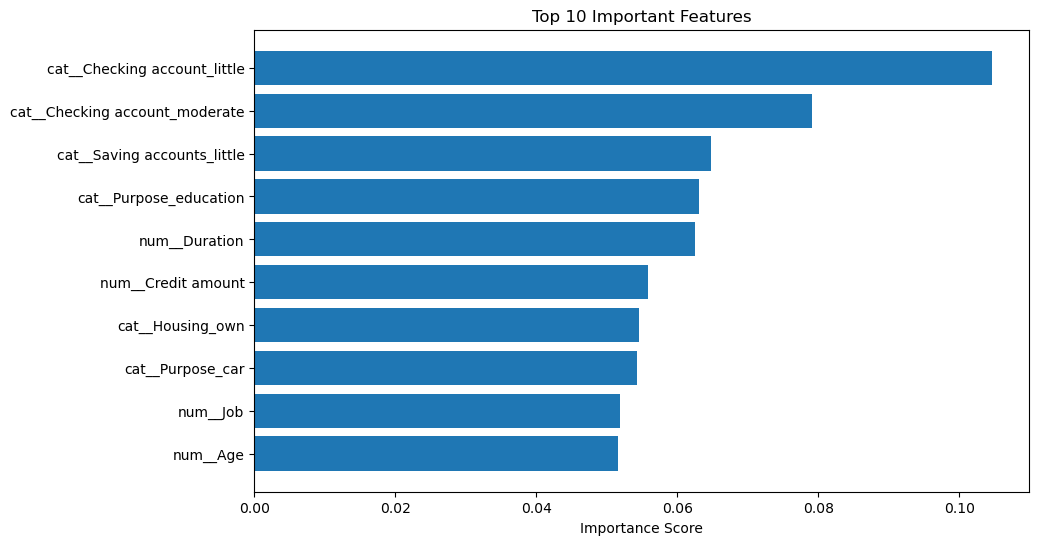

In [55]:
feature_names = pipline_XGB.named_steps['preprocessing'].get_feature_names_out()
importance = pipline_XGB.named_steps['model'].feature_importances_

imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

imp_df = imp_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))

plt.barh(
    imp_df['Feature'][:10],
    imp_df['Importance'][:10]
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()

plt.show()

In [69]:
y_prob = pipline_XGB.predict_proba(x_test)[:, 1]

In [70]:
#roc-Curve and Auc socre
from sklearn.metrics import roc_curve , roc_auc_score
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

print("AUC Score : " , roc_auc.round(2))

AUC Score :  0.79


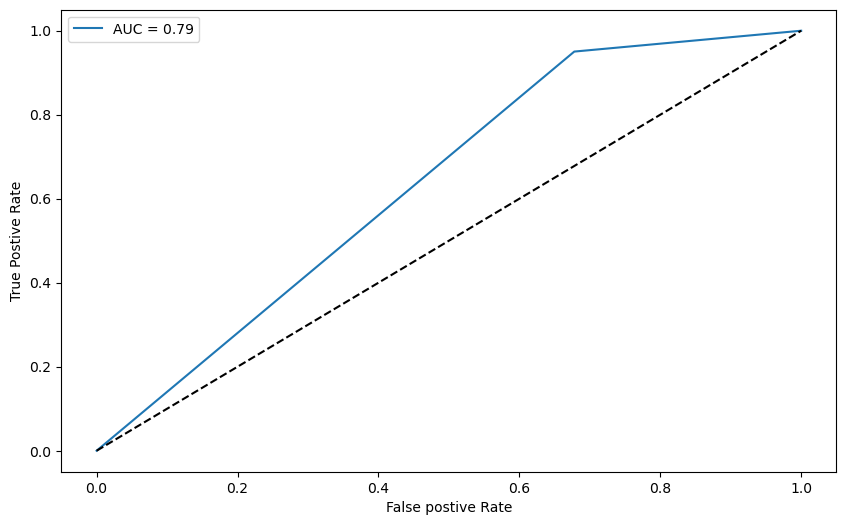

In [71]:
#graph of roc - auc 
plt.figure(figsize = (10 , 6 ))
plt.plot(frp , trp , label = f"AUC = {roc_auc:.2f}")
plt.plot([0 , 1] , [0 , 1 ] , 'k--')


plt.xlabel("False postive Rate")
plt.ylabel("True Postive Rate")
plt.legend()
plt.show()

In [72]:
#All data in Frame 
All_daata = pd.DataFrame({
    'Model' : ['Logistic Regression','Random Forest','XGBoost','XGBoost + SMOTE'],
    'Accuracy' : [0.68,0.76,0.765,0.74],
    'Precision' : [0.818, 0.785, 0.770, 0.799],
    'Recall' : [0.702, 0.908, 0.950, 0.844],
    'F1-Score' : [0.756, 0.842, 0.851, 0.821],
})

print(All_daata)

                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression     0.680      0.818   0.702     0.756
1        Random Forest     0.760      0.785   0.908     0.842
2              XGBoost     0.765      0.770   0.950     0.851
3      XGBoost + SMOTE     0.740      0.799   0.844     0.821


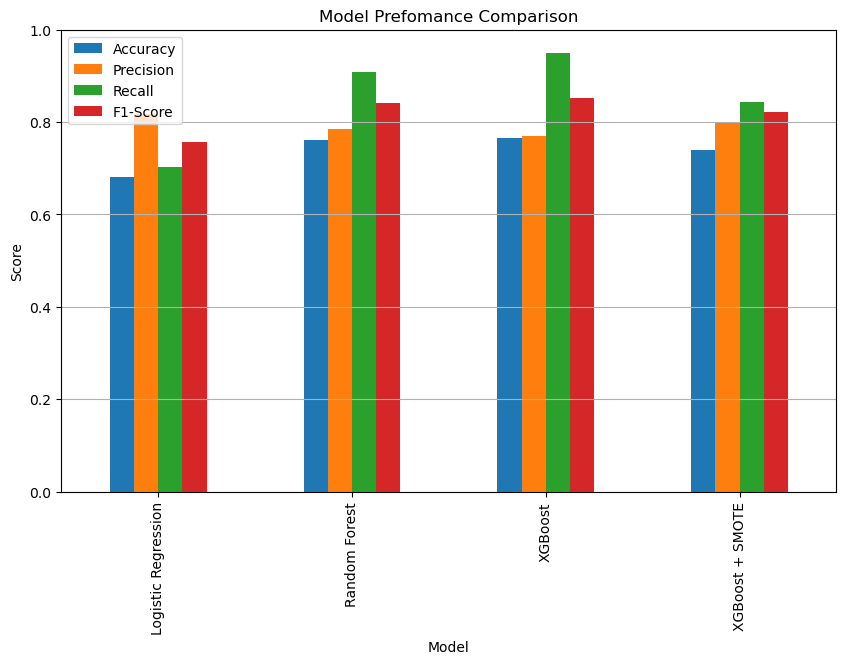

In [76]:
All_daata.set_index('Model').plot(
    kind= 'bar',
    figsize = (10 ,6)
)

plt.title('Model Prefomance Comparison')
plt.ylabel('Score')
plt.ylim( 0, 1)
plt.grid(axis = 'y')
plt.legend()
plt.show()

Average Precision Value :  0.8854563614008608


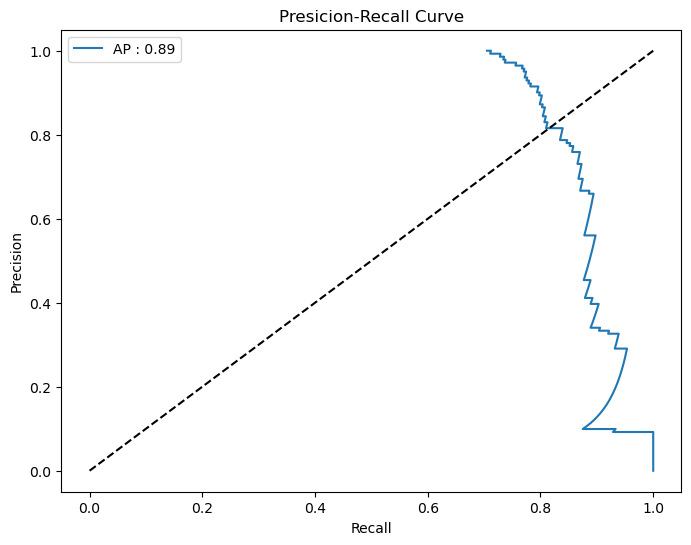

In [79]:
#
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

y_prob = pipline_XGB.predict_proba(x_test)[: , 1]

precision , recall ,threshold = precision_recall_curve(y_test , y_prob)

ap = average_precision_score(y_test , y_prob)
print('Average Precision Value : ' ,  ap)

plt.figure(figsize=(8 , 6))
plt.plot(precision , recall , label = f"AP : {ap:.2f}")
plt.plot([0 , 1] , [0 , 1] , 'k--')

plt.title('Presicion-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

In [83]:
#saving the model
import joblib
joblib.dump(pipline_XGB , 'credit_risk_model.pkl')
print('Model Save SuccessFully')

Model Save SuccessFully


In [84]:
# to check the model its save or not
model = joblib.load('credit_risk_model.pkl')
pred = model.predict(x_test.iloc[[0]])
print(pred)

[1]


In [87]:
df["Credit amount"].describe()

count     1000.000000
mean      3271.258000
std       2822.736876
min        250.000000
25%       1365.500000
50%       2319.500000
75%       3972.250000
max      18424.000000
Name: Credit amount, dtype: float64

In [88]:
df['Duration'].describe()

count    1000.000000
mean       20.903000
std        12.058814
min         4.000000
25%        12.000000
50%        18.000000
75%        24.000000
max        72.000000
Name: Duration, dtype: float64